0. Imports

In [ ]:
%pip install "polars[gpu]" spacy seaborn textstat matplotlib pyarrow && spacy download en_core_web_sm

In [24]:
import os
import re
import json
import polars
import spacy
import seaborn
import textstat
from itertools import permutations
from matplotlib import pyplot


In [2]:
### reusable functions
def load_parquet(parquet_name: str):
    if os.path.exists(parquet_name):
        return polars.read_parquet(parquet_name)


1. CUAD Data loading

In [13]:
if (cuad_legal := load_parquet("0001_cuad_dataset.parquet")) is None:
    with open("./CUADv1.json") as cuad:
        cuad_json = json.load(cuad.buffer)

    legal_pieces = {}
    for data in cuad_json.get("data"):|
        full_context = ""
        for paragraph in data.get("paragraphs"):
            if context := paragraph.get("context", ""):
                full_context += context
        legal_pieces[data.get("title")] = full_context


    cuad_legal = polars.DataFrame(legal_pieces)
    cuad_legal = cuad_legal.transpose(include_header=True)
    cuad_legal.columns = ["title", "paragraphs"]

    ### Parquet checkpoint
    cuad_legal.write_parquet("0001_cuad_dataset.parquet")


2. CUAD Data parsing

In [ ]:
cuad_legal.select("paragraphs")[0,0]


In [3]:
### Functions
def paragraphs_extractor(text):
    splitted = re.split(r"(\n\n|\t|\r|\-*)", text)
    return [re.sub(r"[\s{2,}|\n\|t]", " ", row).lower().strip() for row in splitted if "\n" not in row and row]

def extract_clauses(doc):
    CLAUSE_DEPS = {"ROOT", "ccomp", "xcomp", "advcl", "relcl", "conj"}
    def process_clauses(row):
        clauses = []
        nlp = doc(row)
        for token in nlp:
            if token.pos_ == "VERB" and token.dep_ in CLAUSE_DEPS:
                span = nlp[token.left_edge.i: token.right_edge.i + 1]
                clauses.append(span.text.lower())
        return clauses
    return process_clauses

# Here we are trying to load cached file if it exists, otherwise we will need to reprocess everything
FILENAME = "cuad_sentence_extracted.parquet"

doc = spacy.load("en_core_web_sm")

if os.path.exists(FILENAME):
    cuad_legal = polars.read_parquet(FILENAME)
else:
    ### Logic application to dataset
    cuad_legal = cuad_legal.select("title", "paragraphs").with_columns(
        polars.col("paragraphs").map_elements(
            extract_clauses(doc),
            return_dtype=polars.List(polars.Utf8)
        ).alias("sentences")
    )

## Save checkpoint
cuad_legal.write_parquet("cuad_sentence_extracted.parquet")



3. Applying metrics
    - Flesch-Kincaid Grading
    - Flesch Reading Ease Metric

In [4]:
### Grading the text complexity with Flesch-Kincaid
cuad_legal = cuad_legal.explode("sentences")

# Adding Flesch-Kincaid Grade Level
cuad_legal = cuad_legal.with_columns(polars.col("sentences").map_elements(lambda sentence: textstat.flesch_kincaid_grade(sentence)).alias("fk_grade"))
cuad_legal = cuad_legal.with_columns(polars.col("sentences").map_elements(lambda sentence: textstat.flesch_reading_ease(sentence)).alias("f_reading_ease"))
cuad_legal = cuad_legal.with_columns(polars.col("sentences").map_elements(lambda sentence: textstat.automated_readability_index(sentence)).alias("readability_idx"))


In [5]:
# cuad_legal = cuad_legal.filter(polars.col("fk_grade") > 0)
cuad_legal.head()

# Readability Idx
# ARI      Score	        Grade Level	Typical Reader
# 1–3	   Early elementary	Very easy text
# 4–6	   Upper elementary	Simple prose
# 7–9	   Middle school	Standard writing
# 10–12    High school	    Complex writing
# 13+	   College	        Academic or legal text


title,paragraphs,sentences,fk_grade,f_reading_ease,readability_idx
str,str,str,f64,f64,f64
"""LIMEENERGYCO_09_09_1999-EX-10-…","""EXHIBIT 10.6 …","""exhibit 10.6 …",14.987059,17.891765,15.884118
"""LIMEENERGYCO_09_09_1999-EX-10-…","""EXHIBIT 10.6 …","""which is referred to as an ""e…",11.142857,52.577143,13.517143
"""LIMEENERGYCO_09_09_1999-EX-10-…","""EXHIBIT 10.6 …","""which may be improved or oth…",8.541538,56.978462,12.243077
"""LIMEENERGYCO_09_09_1999-EX-10-…","""EXHIBIT 10.6 …","""otherwise changed from its p…",9.655,40.09,14.95125
"""LIMEENERGYCO_09_09_1999-EX-10-…","""EXHIBIT 10.6 …","""the company may engage in the …",18.37697,22.085455,20.047273


4. Data Visualisation

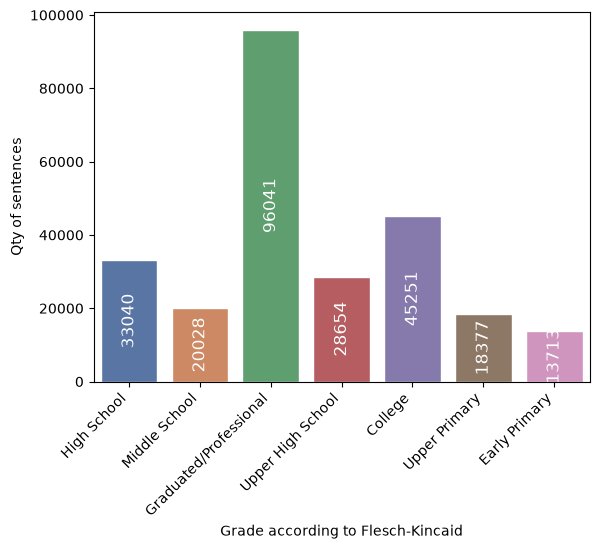

In [6]:
# Prepare and assign items based on Flesch-Kincaid metrics
# cuad_legal.filter(polars.col("fk_grade") > cuad_legal.select("fk_grade").mean()[0,0])
agg_by_grade = cuad_legal.with_columns(
    polars.when(polars.col("fk_grade") <= 3).then(polars.lit("Early Primary"))
    .when(polars.col("fk_grade") <= 6).then(polars.lit("Upper Primary"))
    .when(polars.col("fk_grade") <= 8).then(polars.lit("Middle School"))
    .when(polars.col("fk_grade") <= 10).then(polars.lit("High School"))
    .when(polars.col("fk_grade") <= 12).then(polars.lit("Upper High School"))
    .when(polars.col("fk_grade") <= 15).then(polars.lit("College"))
    .otherwise(polars.lit("Graduated/Professional"))
    .alias("grade_group")
)

pyplot.xticks(rotation=45, ha="right")
pyplot.xlabel("Grade according to Flesch-Kincaid")
pyplot.ylabel("Qty of sentences")
seaborn.set_theme(style="whitegrid")



ax = seaborn.barplot(
    agg_by_grade.group_by("grade_group").agg(polars.col("fk_grade").count()),
    x="grade_group",
    y="fk_grade",
    hue="grade_group"
)


for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height/2, f'{height:.0f}', 
            ha='center', va='center', color='white',rotation=90)



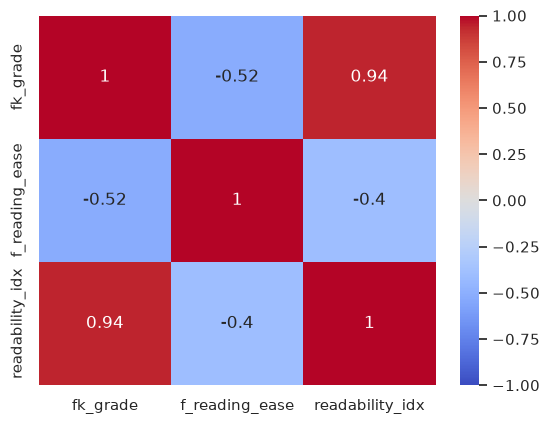

In [51]:
from itertools import permutations

relation_analysis = cuad_legal.filter(
    (polars.col("fk_grade") > 20) &
    (polars.col("f_reading_ease") < 30) &
    (polars.col("f_reading_ease") > 0) &
    (polars.col("readability_idx") > 20)
)

size = int(len(relation_analysis) * 0.02)

relation_analysis = (
    relation_analysis
        .sample(size)
        .select(["fk_grade", "f_reading_ease", "readability_idx"])
        .to_pandas()
)

metrics = permutations(["f_reading_ease", "readability_idx", "fk_grade"], 2)

seaborn.heatmap(
    relation_analysis.corr(method="pearson"),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.show()


| Metric | Description | Scale | Interpretation |
| --- | --- | --- | --- |
| **[Flesch–Kincaid Grade](ca://s?q=Explain_Flesch_Kincaid)** | Estimates U.S. grade level needed to understand the text | ~0–20+ | Higher = more complex; legal text often 14–20 |
| **[Flesch Reading Ease](ca://s?q=Explain_readability_score)** | Measures ease of reading based on sentence length + syllables | 0–100 | Higher = easier; legal text often <30 |
| **[Automated Readability Index](ca://s?q=Explain_Automated_Readability_Index)** | Grade‑level estimate using characters per word + words per sentence | ~0–20+ | Higher = more complex; stable for jargon-heavy text |